# Data Analysis and Visualization in Python

In this workshop you will learn how to work with real-world datasets using:

- **Pandas** for data analysis
- **Matplotlib** for visualization

You will learn how to:

- load datasets
- inspect and understand data
- clean corrupted datasets
- compute summary statistics
- create visualizations

## Setup

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

'/content'

## Loading datasets

Pandas stores tabular data in a structure called a **DataFrame**.

A **Series** represents a single column of data.

In [3]:
# Create sample dataset
np.random.seed(42)
data = {
    'name': ['Alice', 'Bob', 'Charlie', 'Diana', 'Eve', 'Frank', 'Grace', 'Henry', 'Ivy', 'Jack', 'Angie', 'John', 'Evelyn', 'Patrick'],
    'age': [25, 30, 35, 28, 32, 27, 29, 31, 26, 33, 21, 40, 35, 28],
    'salary': [50000, 60000, 80000, 55000, 70000, 45000, 65000, 75000, 52000, 85000, 60000, 87000, 70000, 75000],
    'department': ['IT', 'HR', 'Finance', 'IT', 'Marketing', 'IT', 'Finance', 'HR', 'Marketing', 'Finance', 'HR', 'IT', 'Marketing', 'Finance'],
    'experience': [2, 5, 8, 3, 6, 1, 4, 7, 2, 9, 0, 15, 5, 10]
}

df = pd.DataFrame(data)
df

,name,age,salary,department,experience
0,Alice,25,50000,IT,2
1,Bob,30,60000,HR,5
2,Charlie,35,80000,Finance,8
3,Diana,28,55000,IT,3
4,Eve,32,70000,Marketing,6
5,Frank,27,45000,IT,1
6,Grace,29,65000,Finance,4
7,Henry,31,75000,HR,7
8,Ivy,26,52000,Marketing,2
9,Jack,33,85000,Finance,9


### Functions Fundamentals

1. Display the first 5 rows of the dataframe using `head()`
2. Display information about the dataframe using `info()`
3. Display basic statistics using `describe()`

In [4]:
# Exercise 1: Display first 5 rows
df.head()

,name,age,salary,department,experience
0,Alice,25,50000,IT,2
1,Bob,30,60000,HR,5
2,Charlie,35,80000,Finance,8
3,Diana,28,55000,IT,3
4,Eve,32,70000,Marketing,6


In [ ]:
# Exercise 2: Display information about the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        14 non-null     object
 1   age         14 non-null     int64 
 2   salary      14 non-null     int64 
 3   department  14 non-null     object
 4   experience  14 non-null     int64 
dtypes: int64(3), object(2)
memory usage: 692.0+ bytes


In [ ]:
# Exercise 3: Display basic statistics
df.describe()

,age,salary,experience
count,14.000000,14.000000,14.000000
mean,30.000000,66357.142857,5.500000
std,4.835764,13235.192846,4.071477
min,21.000000,45000.000000,0.000000
25%,27.250000,56250.000000,2.250000
50%,29.500000,67500.000000,5.000000
75%,32.750000,75000.000000,7.750000
max,40.000000,87000.000000,15.000000


### Loading dataset
- CSV with standard comma separator - pd.read_csv('file_name')
- TSV with tab separator - pd.read_csv('file_name', sep='\t')
- json - pd.read_json('file_name')
- excel - pd.read_excel('file_name')

In [7]:
#TODO: Load the dataset `data/organism.csv` into a variable called `df_organism`.
# Display:
#   the first 5 rows
#   basic information about the dataset

df_organism = pd.read_csv("data/organism.csv")

print(df_organism.head())
print(df_organism.info())
print(df_organism.describe())

FileNotFoundError: [Errno 2] No such file or directory: 'data/organism.csv'

## Selecting and filtering columns

In [ ]:
# selecting one column
print(df["name"])

# selecting multiple columns
print(df[["name", "age"]])

0       Alice
1         Bob
2     Charlie
3       Diana
4         Eve
5       Frank
6       Grace
7       Henry
8         Ivy
9        Jack
10      Angie
11       John
12     Evelyn
13    Patrick
Name: name, dtype: object
       name  age
0     Alice   25
1       Bob   30
2   Charlie   35
3     Diana   28
4       Eve   32
5     Frank   27
6     Grace   29
7     Henry   31
8       Ivy   26
9      Jack   33
10    Angie   21
11     John   40
12   Evelyn   35
13  Patrick   28


In [ ]:
# basic filtering
print(df[df["age"] > 30])

# multiple conditions
print(df[(df["age"] > 30) & (df["salary"] > 75000)])

       name  age  salary department  experience
2   Charlie   35   80000    Finance           8
4       Eve   32   70000  Marketing           6
7     Henry   31   75000         HR           7
9      Jack   33   85000    Finance           9
11     John   40   87000         IT          15
12   Evelyn   35   70000  Marketing           5
       name  age  salary department  experience
2   Charlie   35   80000    Finance           8
9      Jack   33   85000    Finance           9
11     John   40   87000         IT          15


In [ ]:
# TODO: select column 'score' for the df_organism
print(df_organism["score"])

# TODO: filter the df_organism dataset to show only rows where score > 9
print(df_organism[df_organism["score"] > 9])

## Modifying data

In [ ]:
# creating new columns
df["experience_days"] = df["experience"] * 365
print(df)

       name  age  salary department  experience  experience_days
0     Alice   25   50000         IT           2              730
1       Bob   30   60000         HR           5             1825
2   Charlie   35   80000    Finance           8             2920
3     Diana   28   55000         IT           3             1095
4       Eve   32   70000  Marketing           6             2190
5     Frank   27   45000         IT           1              365
6     Grace   29   65000    Finance           4             1460
7     Henry   31   75000         HR           7             2555
8       Ivy   26   52000  Marketing           2              730
9      Jack   33   85000    Finance           9             3285
10    Angie   21   60000         HR           0                0
11     John   40   87000         IT          15             5475
12   Evelyn   35   70000  Marketing           5             1825
13  Patrick   28   75000    Finance          10             3650


In [ ]:
# rename
df = df.rename(columns={"experience": "experience_years"})
print(df)

       name  age  salary department  experience_years  experience_days
0     Alice   25   50000         IT                 2              730
1       Bob   30   60000         HR                 5             1825
2   Charlie   35   80000    Finance                 8             2920
3     Diana   28   55000         IT                 3             1095
4       Eve   32   70000  Marketing                 6             2190
5     Frank   27   45000         IT                 1              365
6     Grace   29   65000    Finance                 4             1460
7     Henry   31   75000         HR                 7             2555
8       Ivy   26   52000  Marketing                 2              730
9      Jack   33   85000    Finance                 9             3285
10    Angie   21   60000         HR                 0                0
11     John   40   87000         IT                15             5475
12   Evelyn   35   70000  Marketing                 5             1825
13  Pa

In [ ]:
# TODO: create new column called 'score_scaled' which multiplies score by 10
df_organism["score_scaled"] = df_organism["score"] * 10
print(df_organism)

## Aggregation

- `groupby` - organizing data by grouping rows that share common value
- `mean`, `count` - basic operations over dataframe
- `merge` - merging two dataframes together
- `drop` - deleting column from dataframe

In [ ]:
# Group by department and calculate average salary
df.groupby('department')['salary'].mean()

,salary
department,
Finance,76250.0
HR,65000.0
IT,59250.0
Marketing,64000.0


In [ ]:
# Group by department and count employees
df.groupby('department')['name'].count()

,name
department,
Finance,4
HR,3
IT,4
Marketing,3


In [ ]:
# Group by department and calculate average age
df.groupby('department')['age'].mean()

,age
department,
Finance,31.250000
HR,27.333333
IT,30.000000
Marketing,31.000000


In [ ]:
# Second dataframe with department budgets
budget_data = {
    'department': ['Finance', 'HR', 'IT', 'Marketing'],
    'budget': [500000, 300000, 700000, 400000]
}
budget_df = pd.DataFrame(budget_data)
budget_df

,department,budget
0,Finance,500000
1,HR,300000
2,IT,700000
3,Marketing,400000


### Merging
- how='inner' - intersection of both datasets
- how='left' - all data from the primary dataset and NaN values if the key is missing in the new dataset
- how='right' - all data from the new dataset and NaN values if the key is missing in the primarly dataset
- how='outer' - union of both datasets
- on='column_name' - name of a column that is a key for merging (it needs to exist in both datasets)
- left_on='column_name1', right_on='columnn_name2' - left is the name of the primary dataset column and right is the name of the new dataset column that we want to merge (both columns will be preserved in the merged dataset!)

In [ ]:
# Merge the original dataframe with the budget dataframe
merged_df = pd.merge(df, budget_df, on='department', how='left')
merged_df

,name,age,salary,department,experience_years,experience_days,budget
0,Alice,25,50000,IT,2,730,700000
1,Bob,30,60000,HR,5,1825,300000
2,Charlie,35,80000,Finance,8,2920,500000
3,Diana,28,55000,IT,3,1095,700000
4,Eve,32,70000,Marketing,6,2190,400000
5,Frank,27,45000,IT,1,365,700000
6,Grace,29,65000,Finance,4,1460,500000
7,Henry,31,75000,HR,7,2555,300000
8,Ivy,26,52000,Marketing,2,730,400000
9,Jack,33,85000,Finance,9,3285,500000


In [ ]:
# TODO: Group df_organism by year and calculate average score
print(df_organism.groupby("year")["score"].mean())

# TODO: Group df_organism by year and count the organisms
print(df_organism.groupby("year")["organism"].count())

# TODO: load second dataset from "data/habitats.csv"
df_habitats = pd.read_csv("data/habitats.csv")
print(df_habitats)

# TODO: Merge df_organism and the new dataset
merged = pd.merge(df_organism, df_habitats, on="organism", how="left")
print(merged)


## Work with error in data

- .isna() - missing data
- .fillna() - missing data
- .astype() - wrong data types
- .duplicated() - duplicated data

In [ ]:
research_data = {
    'project_id': ['RES-001', 'RES-002', 'RES-003', 'RES-004', 'RES-001'],
    'researcher': ['Dr. Aris', 'Dr. Aris', 'Prof. Bell', 'Dr. Chen', 'Dr. Aris'],
    'funding_usd': [50000, "75000", 120000, 45000, 50000],
    'samples_collected': [120, 150, None, 90, 120],
    'success_rate': [0.85, 0.92, 0.78, 0.88, 0.85],
    'status': ['Completed', 'Ongoing', 'Completed', 'Ongoing', 'Completed']
}

# TODO: do dataframe out of research_data (use unique name for the dataframe so you dont overwrite dataframes we already created!)
df_research = pd.DataFrame(research_data)
print(df_research)

In [ ]:
# TODO: calculate average funding
print(df_research["funding_usd"].mean())


In [ ]:
# TODO: calculate sum of collected samples
print(df_research["samples_collected"].sum())


In [ ]:
# TODO: calculate unique number of projects
print(df_research["project_id"].count())


## Matplotlib

### Fundamentals

- `plt.plot, plt.hist, plt.scatter, plt.boxplot`
- heatmaps
- descriptions, names
- visualizing multiple datasets
- too many functions and parameters - AI generation of the visualizations


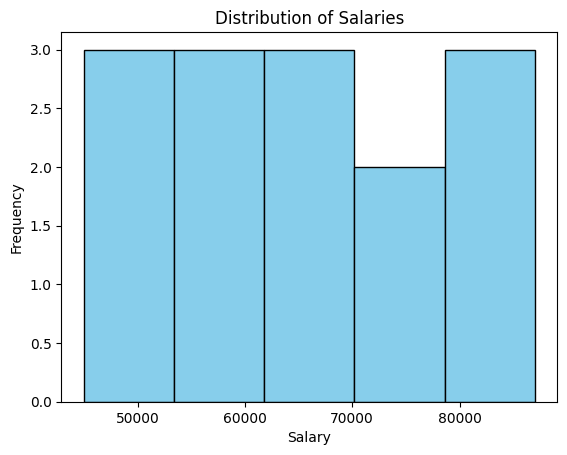

In [ ]:
# Histogram of salaries
plt.hist(df['salary'], bins=5, color='skyblue', edgecolor='black')

plt.title('Distribution of Salaries')

plt.xlabel('Salary')

plt.ylabel('Frequency')

plt.show()

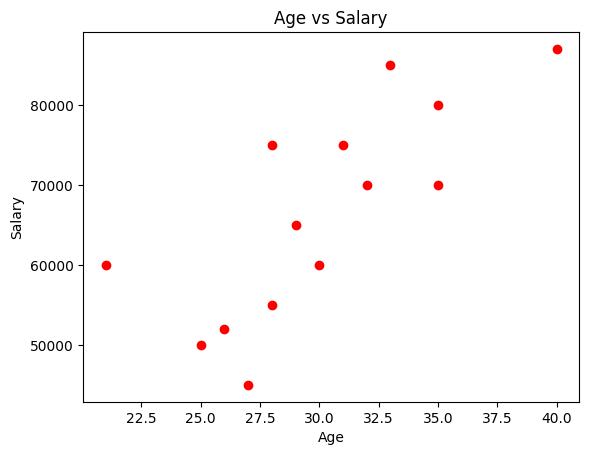

In [ ]:
# Scatter plot of age vs salary
plt.scatter(df['age'], df['salary'], color='red')

plt.title('Age vs Salary')

plt.xlabel('Age')

plt.ylabel('Salary')

plt.show()

department
Finance      76250.0
HR           65000.0
IT           59250.0
Marketing    64000.0
Name: salary, dtype: float64


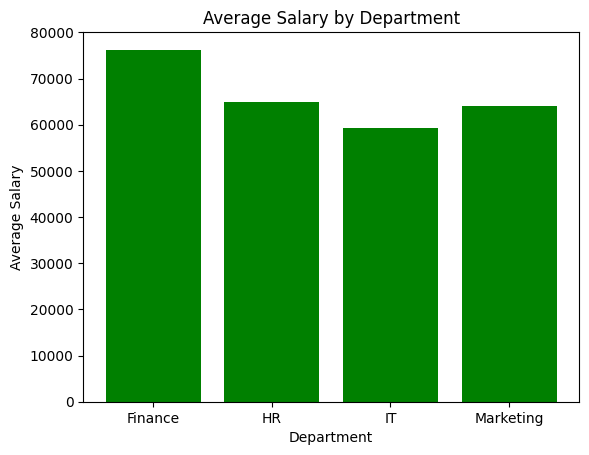

In [ ]:
# Bar chart of average salary by department
dept_avg_salary = df.groupby('department')['salary'].mean()

print(dept_avg_salary)

plt.bar(dept_avg_salary.index, dept_avg_salary.values, color='green')

plt.title('Average Salary by Department')

plt.xlabel('Department')

plt.ylabel('Average Salary')

plt.show()

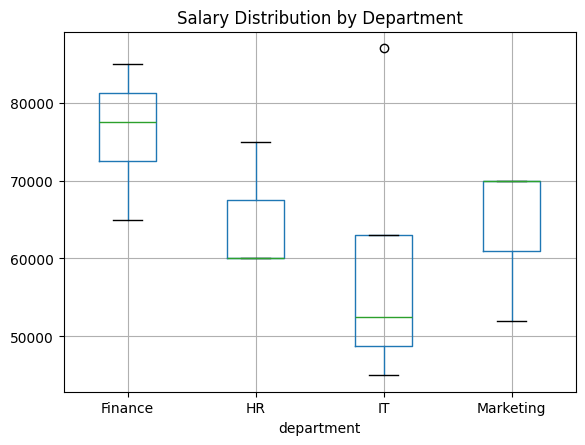

In [ ]:
# Box plot of salaries by department
df.boxplot(column='salary', by='department', ax=plt.gca())

plt.title('Salary Distribution by Department')

plt.suptitle('')  # Remove automatic title

plt.show()

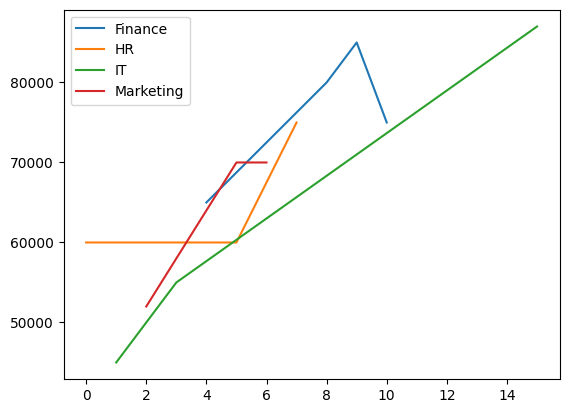

In [ ]:
# Plotting things together to get overview
finance = df[df["department"] == "Finance"].groupby("experience_years")["salary"].mean()
hr = df[df["department"] == "HR"].groupby("experience_years")["salary"].mean()
it = df[df["department"] == "IT"].groupby("experience_years")["salary"].mean()
marketing = df[df["department"] == "Marketing"].groupby("experience_years")["salary"].mean()

plt.plot(finance.index, finance.values, label="Finance")
plt.plot(hr.index, hr.values, label="HR")
plt.plot(it.index, it.values, label="IT")
plt.plot(marketing.index, marketing.values, label="Marketing")
plt.legend()
plt.show()

# we can definitely do it some more efficient way. Can you tell how?


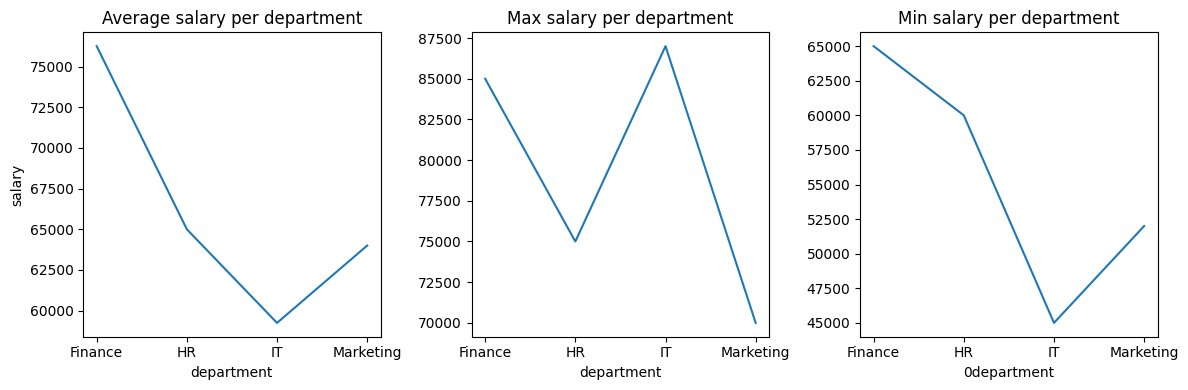

In [ ]:
# Subplots
mean_salary = df.groupby("department")["salary"].mean()
max_salary = df.groupby("department")["salary"].max()
min_salary = df.groupby("department")["salary"].min()

# plots
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].plot(mean_salary.index, mean_salary.values)
axes[0].set_title("Average salary per department")
axes[0].set_xlabel("department")
axes[0].set_ylabel("salary")

axes[1].plot(max_salary.index, max_salary.values)
axes[1].set_title("Max salary per department")
axes[1].set_xlabel("department")

axes[2].plot(min_salary.index, min_salary.values)
axes[2].set_title("Min salary per department")
axes[2].set_xlabel("0department")

plt.tight_layout()
plt.show()

In [ ]:
# TODO: make histogram of column 'score' in df_organism


In [ ]:
# TODO: show relationship with scatter plot between 'size' and 'score' columns


## Mini-project
Let's work with a more complex dataset. We'll load dataset paper.csv and work with it to practice our skills.

1. Load and explore the dataset papers.csv
2. Clean the data
    - use .isna(), .fillna() and .dropna()
    - check if the datatypes are correct
3. Perform calculations
    - calculate number of papers per year
    - calculate average of citations per field
4. Create visualizations
    - visualize the relationship between authors and citations
    - show the distribution of citations
    - show average citations per field computed in previous step

In [ ]:
# code here



## Key findings

In this workshop you learned:

- how to load datasets using Pandas
- how to inspect and filter data
- how to clean missing values
- how to compute statistics
- how to create visualizations with Matplotlib